<a href="https://colab.research.google.com/github/jgpranto/Blockchain-Smart-Contract-Certification-Verification/blob/main/cliff-walking_tabular_from_scratch/Cliff_Walking_Without_import.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

env= gym.make('CliffWalking-v1')

n_states = env.observation_space.n
n_actions = env.action_space.n

In [ ]:
# SARSA algorithm
alpha = 0.1
gamma = 0.99
epsilon = 0.3
episodes = 500

q_table_sarsa = np.zeros((n_states, n_actions))
rewards_sarsa = []

def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[state])

for i in range(episodes):
    state, _ = env.reset()
    action = choose_action(state, q_table_sarsa, epsilon)
    total_reward = 0
    done = False

    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_action = choose_action(next_state, q_table_sarsa, epsilon)

        current_q = q_table_sarsa[state, action]
        next_q = q_table_sarsa[next_state, next_action] if not done else 0.0

        q_table_sarsa[state, action] = current_q + alpha * (reward + gamma * next_q - current_q)

        state = next_state
        action = next_action
        total_reward += reward

    rewards_sarsa.append(total_reward)

print("SARSA Training Complete! The agent has filled out the Q-Table.")

SARSA Training Complete! The agent has filled out the Q-Table.


In [ ]:
# Q-Learning algorithm
alpha = 0.1
gamma = 0.99
epsilon = 0.3
episodes = 500

q_table_q = np.zeros((n_states, n_actions))
rewards_q = []

def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(q_table[state])

for i in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = choose_action(state, q_table_q, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        current_q = q_table_q[state, action]
        next_q = np.max(q_table_q[next_state]) if not done else 0.0

        q_table_q[state, action] = current_q + alpha * (reward + gamma * next_q - current_q)

        state = next_state
        total_reward += reward

    rewards_q.append(total_reward)

print("Q-Learning Training Complete! The agent has filled out the Q-Table.")

Q-Learning Training Complete! The agent has filled out the Q-Table.


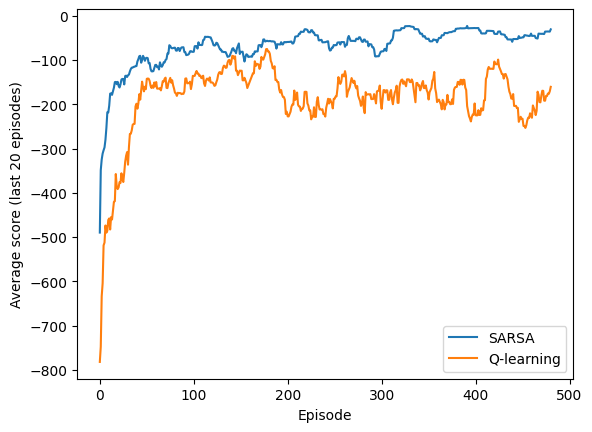

In [ ]:
window = 20
plt.plot(np.convolve(rewards_sarsa, np.ones(window)/window, mode='valid'), label='SARSA')
plt.plot(np.convolve(rewards_q, np.ones(window)/window, mode='valid'), label='Q-learning')
plt.xlabel('Episode')
plt.ylabel('Average score (last 20 episodes)')
plt.legend()
plt.show()